In [1]:
from ml_enhance import QuantumFPFileLoader, parallelize
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from pathlib import Path
from collections import Counter

In [62]:
path = Path("../data/QuantumFP/QFP_output")

In [63]:
loader = QuantumFPFileLoader(path)
output_files = loader.list_output_files()

In [3]:
analysis_df = pd.DataFrame(columns=["id", "num_conformers", "num_neg_freq", "max_neg_freq", "min_neg_freq", "avg_neg_freq"])

In [4]:
analysis_df

,id,num_conformers,num_neg_freq,max_neg_freq,min_neg_freq,avg_neg_freq


In [ ]:
def get_df_len(file: Path) -> tuple[int, list[float]]:
    for df in loader.stream_conformer_dataframe(file):
        conformer_freqs = df["normal_mode_frequencies"].to_numpy()
        neg_freqs = [freq for freqs in conformer_freqs for freq in freqs if freq < 0]

        
        max_neg_freq = 0 if len(neg_freqs) == 0 else max(neg_freqs)
        min_neg_freq = 0 if len(neg_freqs) == 0 else min(neg_freqs)
        avg_neg_freq = 0 if len(neg_freqs) == 0 else np.mean(neg_freqs)

        new_df = {
            "id": df["id"][0],
            "num_conformers": len(df),
            "neg_freqs": neg_freqs,
            "num_neg_freqs": len(neg_freqs),
            "max_neg_freqs": max_neg_freq,
            "min_neg_freqs": min_neg_freq,
            "avg_neg_freqs": avg_neg_freq
                  }
         
        return new_df

In [6]:
results = parallelize(get_df_len, output_files)

100%|██████████| 8837/8837 [25:57<00:00,  5.68it/s]  


In [24]:
analysis_df = pd.read_json("../data/sandbox_data/conformers_and_neg_freqs_df.json")
analysis_df.head()

,id,num_conformers,neg_freqs,num_neg_freqs,max_neg_freqs,min_neg_freqs,avg_neg_freqs
0,{'0': 0},1,[],0,0.000000,0.000000,0.000000
1,{'0': 1},1,[],0,0.000000,0.000000,0.000000
2,"{'0': 10, '1': 10, '2': 10, '3': 10, '4': 10, ...",19,[],0,0.000000,0.000000,0.000000
3,"{'0': 100, '1': 100, '2': 100, '3': 100, '4': ...",7,[-19.8778994396],1,-19.877899,-19.877899,-19.877899
4,"{'0': 1000, '1': 1000, '2': 1000, '3': 1000, '...",10,[],0,0.000000,0.000000,0.000000


In [20]:
list(analysis_df["id"][4].values())[0]

1000

In [32]:
analysis_df["ID"] = analysis_df["id"].apply(lambda x: list(x.values())[0])

In [36]:
analysis_df = analysis_df.drop("id", axis=1)

In [41]:
negative_freq_df = analysis_df[analysis_df["num_neg_freqs"] > 0]
negative_freq_df

,num_conformers,neg_freqs,num_neg_freqs,max_neg_freqs,min_neg_freqs,avg_neg_freqs,ID
3,7,[-19.8778994396],1,-19.877899,-19.877899,-19.877899,100
5,32,"[-45.5401234664, -44.2232560066, -41.090821860...",5,-32.051569,-53.856056,-43.352365,1001
6,30,"[-93.0843101613, -92.7394554432, -12.040781199...",4,-12.040781,-93.084310,-72.583061,1002
8,32,[-8.7912855338],1,-8.791286,-8.791286,-8.791286,1004
9,27,"[-3.4245618969000002, -5.0992508429, -0.679322...",3,-0.679323,-5.099251,-3.067712,1005
...,...,...,...,...,...,...,...
8827,32,"[-11.9075613159, -3.7145008279000002, -2.91517...",5,-2.915174,-15.265767,-9.117719,990
8830,32,"[-0.7237507669000001, -2.6930059651000002]",2,-0.723751,-2.693006,-1.708378,993
8832,22,"[-7.2891076622, -7.113884999, -6.9789417819, -...",5,-4.978098,-7.459889,-6.763984,995
8833,32,[-3.7945402684],1,-3.794540,-3.794540,-3.794540,996


In [97]:
filtered = negative_freq_df.nsmallest(10, "max_neg_freqs")
filtered_max = filtered[filtered["num_conformers"] < 10]

file_names = [f"internship_smiles2_{id}.json.gz" for id in filtered_max["ID"]]
filtered

,num_conformers,neg_freqs,num_neg_freqs,max_neg_freqs,min_neg_freqs,avg_neg_freqs,ID
1128,1,[-421.2645397777],1,-421.264540,-421.264540,-421.264540,2015
2769,1,[-389.3432695706],1,-389.343270,-389.343270,-389.343270,3495
7633,2,[-362.836203857],1,-362.836204,-362.836204,-362.836204,7875
3220,1,[-351.5440779117],1,-351.544078,-351.544078,-351.544078,3900
7377,1,[-343.8983301295],1,-343.898330,-343.898330,-343.898330,7644
3686,4,[-317.8381678234],1,-317.838168,-317.838168,-317.838168,432
7395,27,[-316.7711790863],1,-316.771179,-316.771179,-316.771179,7660
3538,21,[-311.7519757319],1,-311.751976,-311.751976,-311.751976,4187
8553,7,[-310.9651878659],1,-310.965188,-310.965188,-310.965188,8702
2501,2,[-301.322175405],1,-301.322175,-301.322175,-301.322175,3253


In [98]:
def canonicalize_smiles(smiles: str) -> str | None:
    if not isinstance(smiles, str):
        return None

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    for atom in mol.GetAtoms():
        atom.SetAtomMapNum(0)

    return Chem.MolToSmiles(mol, canonical=True)

In [99]:
smiles = []
for file_name in file_names:
    for df in loader.stream_conformer_dataframe(path / file_name):
        # print(df["original_smiles"].values[0])
        smiles.append(df["original_smiles"].values[0])

print(smiles)

filtered_max["smiles"] = smiles
filtered_max["canon_smiles"] = filtered_max["smiles"].apply(canonicalize_smiles)

['[N:1]([c:2]1[c:3]([H:14])[c:4]([H:15])[c:5]2[n:6]([H:16])[c:7](=[O:8])[n:9]([H:17])[c:10]2[c:11]1[H:18])([H:12])[H:13]', '[N:1]([c:2]1[c:3]([H:18])[c:4]([H:19])[c:5]2[c:6]([H:20])[c:7]3[c:8]([H:21])[c:9]([H:22])[c:10]([H:23])[c:11]([H:24])[c:12]3[c:13]([H:25])[c:14]2[c:15]1[H:26])([H:16])[H:17]', '[N:1]([c:2]1[c:3]2[n:4]([H:15])[c:5](=[O:6])[n:7][c:8]-2[n:9]([H:16])[c:10](=[O:11])[n:12]1[H:17])([H:13])[H:14]', '[N:1]([c:2]1[c:3]([H:12])[c:4]([H:13])[c:5]([H:14])[c:6]([C:8]#[N:9])[c:7]1[H:15])([H:10])[H:11]', '[s:1]1[c:2]([N:3]([H:7])[H:8])[n:4][c:5]([H:9])[c:6]1[H:10]', '[N:1]([c:2]1[c:3]([H:18])[c:4]([H:19])[c:5]([N:8]=[N:9][c:10]2[c:11]([H:22])[c:12]([H:23])[c:13]([H:24])[c:14]([H:25])[c:15]2[H:26])[c:6]([H:20])[c:7]1[H:21])([H:16])[H:17]', '[C:1]([C:2]([C:3]([O:4][C:5](=[O:6])[c:7]1[c:8]([H:21])[c:9]([H:22])[c:10]([N:11]([H:23])[H:24])[c:12]([H:25])[c:13]1[H:26])([H:19])[H:20])([H:17])[H:18])([H:14])([H:15])[H:16]', '[N:1]([c:2]1[c:3]([H:10])[c:4]([H:11])[n:5][c:6]([H:12])[c:7]1[H

In [100]:
filtered_max.to_json("most_negative_frequencies.json")

In [103]:
filtered_max

,num_conformers,neg_freqs,num_neg_freqs,max_neg_freqs,min_neg_freqs,avg_neg_freqs,ID,smiles,canon_smiles
1128,1,[-421.2645397777],1,-421.264540,-421.264540,-421.264540,2015,[N:1]([c:2]1[c:3]([H:14])[c:4]([H:15])[c:5]2[n...,Nc1ccc2[nH]c(=O)[nH]c2c1
2769,1,[-389.3432695706],1,-389.343270,-389.343270,-389.343270,3495,[N:1]([c:2]1[c:3]([H:18])[c:4]([H:19])[c:5]2[c...,Nc1ccc2cc3ccccc3cc2c1
7633,2,[-362.836203857],1,-362.836204,-362.836204,-362.836204,7875,[N:1]([c:2]1[c:3]2[n:4]([H:15])[c:5](=[O:6])[n...,Nc1[nH]c(=O)[nH]c2nc(=O)[nH]c1-2
3220,1,[-351.5440779117],1,-351.544078,-351.544078,-351.544078,3900,[N:1]([c:2]1[c:3]([H:12])[c:4]([H:13])[c:5]([H...,N#Cc1cccc(N)c1
7377,1,[-343.8983301295],1,-343.898330,-343.898330,-343.898330,7644,[s:1]1[c:2]([N:3]([H:7])[H:8])[n:4][c:5]([H:9]...,Nc1nccs1
3686,4,[-317.8381678234],1,-317.838168,-317.838168,-317.838168,432,[N:1]([c:2]1[c:3]([H:18])[c:4]([H:19])[c:5]([N...,Nc1ccc(N=Nc2ccccc2)cc1
8553,7,[-310.9651878659],1,-310.965188,-310.965188,-310.965188,8702,[C:1]([C:2]([C:3]([O:4][C:5](=[O:6])[c:7]1[c:8...,CCCOC(=O)c1ccc(N)cc1
2501,2,[-301.322175405],1,-301.322175,-301.322175,-301.322175,3253,[N:1]([c:2]1[c:3]([H:10])[c:4]([H:11])[n:5][c:...,Nc1ccncc1


In [102]:
# analysis_df = pd.DataFrame(results)
# analysis_df["ID"] = analysis_df["id"].apply(lambda x: x[0])
# analysis_df.head()

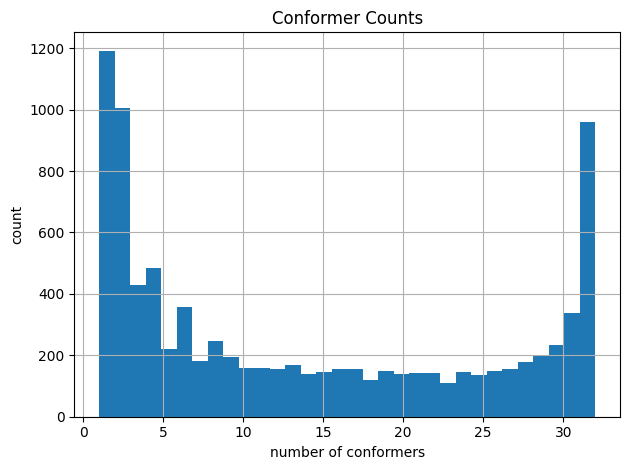

In [51]:
plt.hist(analysis_df["num_conformers"], bins=32)

plt.xlabel("number of conformers")
plt.ylabel("count")
plt.grid(True)
plt.title("Conformer Counts")
plt.tight_layout()
plt.savefig("Conformer_Counts.png")
plt.show()

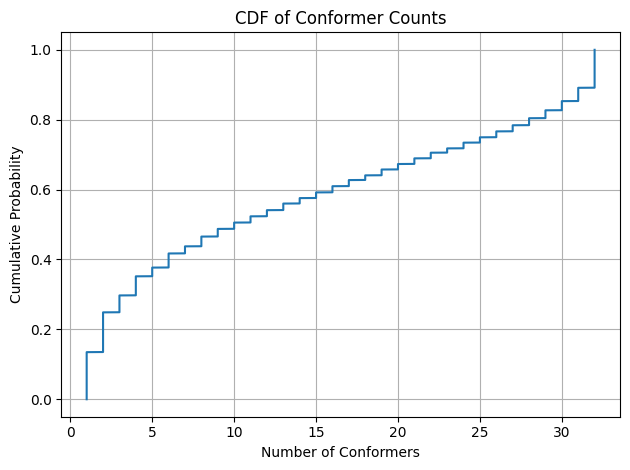

In [52]:
# Sort values
sorted_conf = np.sort(analysis_df["num_conformers"])

# Compute cumulative probabilities
cdf = np.arange(1, len(sorted_conf)+1) / len(sorted_conf)

plt.figure()
plt.plot(sorted_conf, cdf)
plt.xlabel("Number of Conformers")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Conformer Counts")
plt.grid(True)
plt.tight_layout()
plt.savefig("CDF_of_Conformer_Counts.png")
plt.show()

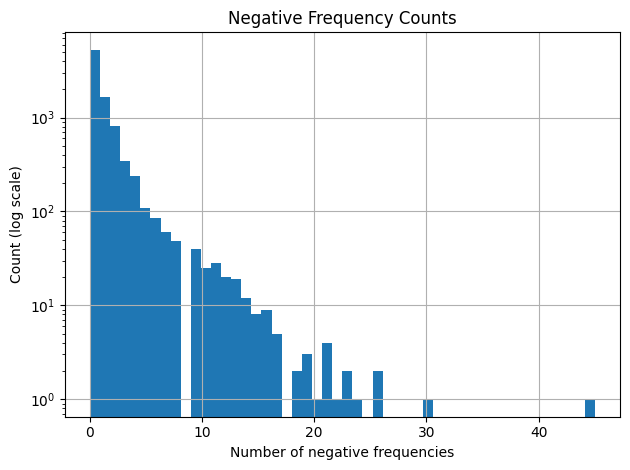

In [53]:
plt.hist(analysis_df["num_neg_freqs"], bins=50)
plt.yscale("log")

plt.xlabel("Number of negative frequencies")
plt.ylabel("Count (log scale)")
plt.grid(True)
plt.title("Negative Frequency Counts")
plt.tight_layout()
plt.savefig("Negative_Frequency_Counts.png")
plt.show()

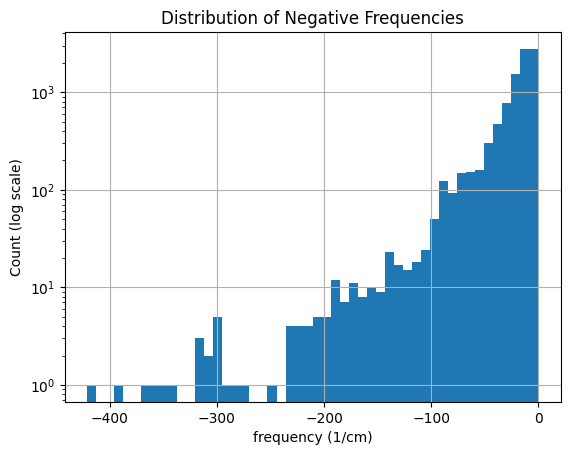

In [54]:
freqs = [freq for mol_freqs in analysis_df["neg_freqs"] for freq in mol_freqs]
plt.hist(freqs, bins=50)

plt.yscale("log")

plt.xlabel("frequency (1/cm)")
plt.ylabel("Count (log scale)")
plt.title("Distribution of Negative Frequencies")
plt.grid(True)
plt.savefig("Distribution_of_Negative_Frequencies.png")
plt.show()

Text(0, 0.5, 'Number of negative frequencies')

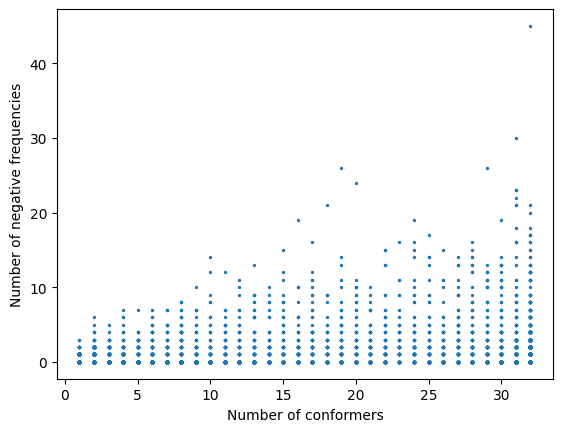

In [45]:
plt.scatter(analysis_df["num_conformers"], analysis_df["num_neg_freqs"], s=2)

plt.xlabel("Number of conformers")
plt.ylabel("Number of negative frequencies")